#[Assignment 7] 🥽 Logistic Regression vs KNN

In this assignment, we’ll explore the Glass Identification dataset (Kaggle):

👉 https://www.kaggle.com/datasets/uciml/glass

The dataset contains measurements of different glass samples, such as refractive index and element concentrations (like Na, Mg, Al, Si, K, Ca, Ba, Fe). Each record is labeled with a glass type (1–7), representing different categories of glass.

Just as logistic regression serves as a strong baseline classifier 📊, this assignment expands your skills by comparing it with K-Nearest Neighbors (KNN) 🤝. By the end, you’ll see how these two approaches differ in handling a multi-class classification problem.

Your tasks are to:

1.   🟦 Prepare the dataset by normalizing features (important for KNN).
2.   🟨 Split the data into training and test sets (use random_state=10 for consistency).
3.   🔢 Train KNN models with different values of k (2, 3, 4, 5).
4.   🟩 Train a Logistic Regression model via grid search.


## Step 1: Setup

Download the csv file named **glass.csv**, upload it to your colab and load it to a DataFrame named `data`

Dataset reference:
https://www.kaggle.com/datasets/uciml/glass

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
data=pd.read_csv('glass.csv')
print("The number of records in this dataset is ", len(data))

The number of records in this dataset is  214


In [2]:
data.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


## Step 2: Defining the Problem

In this dataset, we want to solve a **multi-class classification** problem:
*   The **Type** column is the **label** (target).
*   All the other columns are the **features** (inputs).

Our goal is to train a model that learns from the features and correctly predicts the **Type** of each sample. 🎯


## Step 3: Data Encoding

Data Encoding is not needed because all columns are numberical as shown in the result of **data.info()**

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


##Step 4: Label Analysis

Run the following command to check the values in the **label (Type) column**.
You’ll notice:

*   There are **7 possible classes, numbered from 1 to 7**.
*   Looking at the histogram, the dataset is **imbalanced** — some classes have many more records than others.
*   Class 4 has no records at all. We can confirm this by running:


```
data[data['Type'] == 4]
```

which returns an empty result.

In [4]:
data['Type']

0      1
1      1
2      1
3      1
4      1
      ..
209    7
210    7
211    7
212    7
213    7
Name: Type, Length: 214, dtype: int64

<Axes: >

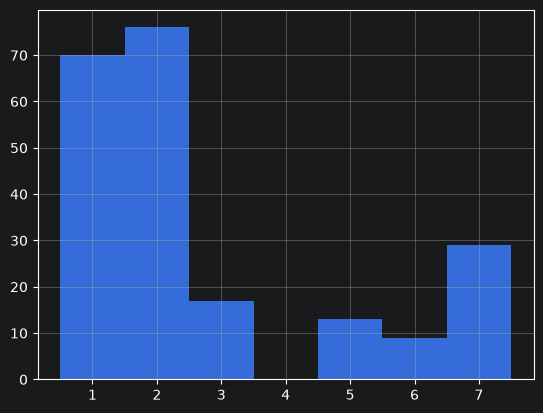

In [5]:
data['Type'].hist(bins=[0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5])

In [6]:
data[data['Type']==4]

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type


## Step 5: Normalize Data [2 points]

Use `StandardScaler` from `Scikit-learn` to normalize all the feature columns (but exclude the label).
*   Store the normalized features in a DataFrame named `data_n_df`.
*   Make sure that all the original column names are preserved. ✅

In [10]:
from sklearn.preprocessing import StandardScaler
### BEGIN SOLUTION
scaler = StandardScaler()
scaler.fit(data.drop(columns='Type'))
data_n = scaler.transform(data.drop(columns='Type'))
data_n_df = pd.DataFrame(data_n, columns=data.drop(columns='Type').columns)
### END SOLUTION

In [11]:
#if you did the normalization correct, the follwoing command should print True
round(data_n_df['RI'].mean())+round(data_n_df['K'].mean())==0

True

## Step 6: Data Split [2 points]

Use  `train_test_split` from Scikit-learn and split the Features and Label(Y) to **70%** training subset and **30%** test subset. Use the variable names as shown below.

<font color=red>You **must** use `random_state=10` to get the result needed.</font>

In [13]:
from sklearn.model_selection import train_test_split
### BEGIN SOLUTION
X_train, X_test, Y_train, Y_test = train_test_split(data_n_df, data['Type'], test_size=0.3, random_state=10)

### END SOLUTION

<Axes: >

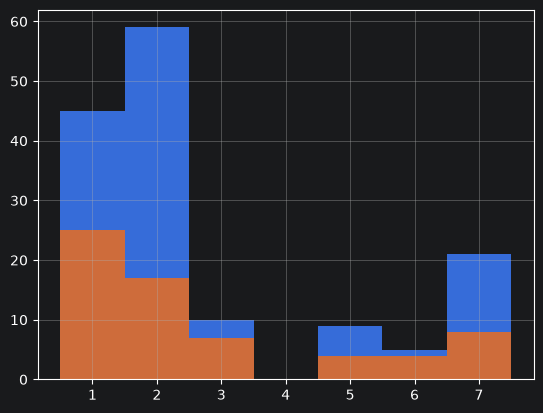

In [14]:
#Review the following histograms and see how data is split.
Y_train.hist(bins=[0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5])
Y_test.hist(bins=[0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5])

## Step 7: KNN [4 points]

Train KNN for K=2,3,4,5

*   Store the accuracy of the 4 models in a list named `accuracy_list`  
*   Store the f1-score of the 4 models in a list named `f1_score_list`

When your code finishes, Each list should have 4 numbers in this order: the first number for the 2NN Model, the second number is for the 3NN Model,...

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,f1_score
### BEGIN SOLUTION
accuracy_list=[]
f1_score_list=[]

for k in range(2,6):
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,Y_train)
    Y_predict=knn.predict(X_test)
    accuracy_list.append(accuracy_score(Y_test,Y_predict))
    f1_score_list.append(f1_score(Y_test,Y_predict, average='weighted'))

print (accuracy_list, f1_score_list)
### END SOLUTION

[0.5384615384615384, 0.5076923076923077, 0.5384615384615384, 0.5230769230769231] [0.4957185864068455, 0.4846153846153846, 0.5156885667523966, 0.50416884702599]


Based on the plot, we can decide what to use for K in KNeighborsClassifier.

Text(0.5, 1.0, 'Evaluation metrics vs. K')

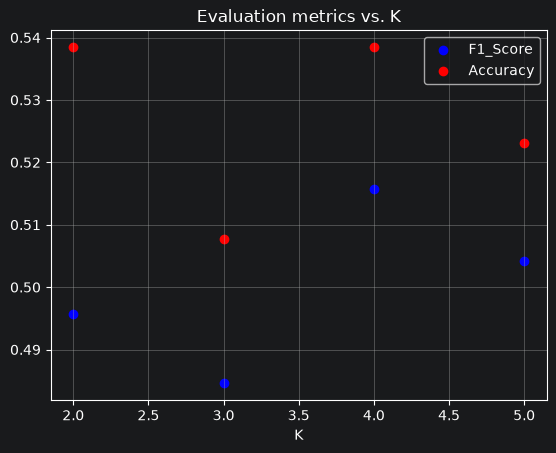

In [16]:
#If you wrote the code correctly, running the following code, should create a plot of accuracy and f1-score of different models compared agains each other.
import matplotlib.pyplot as plt
plt.scatter(range(2,6),f1_score_list,label='F1_Score',color='blue')
plt.scatter(range(2,6),accuracy_list,label='Accuracy',color='red')
plt.xlabel('K')
plt.legend()
plt.grid()
plt.title('Evaluation metrics vs. K')

##Step 8: KNN- Best [1 point]

Useing the graph in the previous step, decide on the best K and train the model using the selected K and store test data predictions in a variable named `Y_testing_predicted`

In [17]:
from sklearn.neighbors import KNeighborsClassifier
### BEGIN SOLUTION
best_k = 4 # Highest f1-score and highest accuracy

model=KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train,Y_train)
Y_testing_predicted=model.predict(X_test)
### END SOLUTION

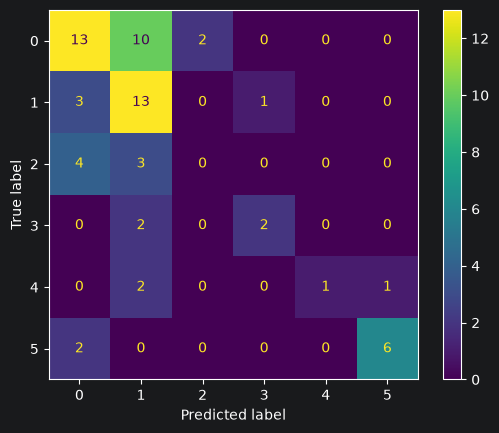

In [18]:
#Run the following commands to get the Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix(Y_test,Y_testing_predicted))
disp.plot()


## Step 9: Logistic Regression - Grid Search [3 points]

Train Logistic Regression for all the combination of param_cases given below using GridSearchCV

In [19]:
param_cases={
    'class_weight':['balanced'],
    'solver' : ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
    'max_iter' : [25, 50]
}

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
### BEGIN SOLUTION
Model_G = LogisticRegression()
Model_Grid = GridSearchCV(estimator=Model_G,param_grid=param_cases,cv=5)
Model_Best = Model_Grid.fit(X_train,Y_train)

### END SOLUTION

/home/scott/PycharmProjects/grad-school/.venv/lib64/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 25 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=25).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/scott/PycharmProjects/grad-school/.venv/lib64/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 25 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=25).
You might also want to scale the data as shown in:
    https://s

In [21]:
#Running this command should give you the model parameters which resulted in the best accuracy_score
Model_Best.best_estimator_

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'newton-cg'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",25
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength;

In [22]:
#Running this command should give you a nice tablecomparing all models.

pd.concat([pd.DataFrame(Model_Best.cv_results_["params"]),pd.DataFrame(Model_Best.cv_results_["mean_test_score"], columns=["Accuracy"])],axis=1)


,class_weight,max_iter,solver,Accuracy
0,balanced,25,newton-cg,0.591264
1,balanced,25,lbfgs,0.591264
2,balanced,25,liblinear,NaN
3,balanced,25,sag,0.570805
4,balanced,25,saga,0.584138
5,balanced,50,newton-cg,0.591264
6,balanced,50,lbfgs,0.591264
7,balanced,50,liblinear,NaN
8,balanced,50,sag,0.591264
9,balanced,50,saga,0.577471


## Step 10: Logistic Regression - Best

Running the following command should give you a confusion matrix of the best logistic regression model!

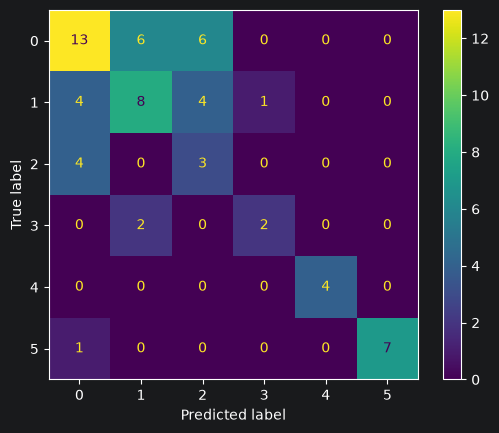

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix(Y_test,Model_Best.best_estimator_.predict(X_test)))
disp.plot()
